# Phase 07 — Customer Churn Prediction

---

# 1. Business Problem

Customer retention is one of the biggest challenges faced by e-commerce businesses. Acquiring a new customer is significantly more expensive than retaining an existing one. Therefore, identifying customers who are likely to stop purchasing allows businesses to take proactive actions before losing them permanently.

The objective of this phase is to build a machine learning model that predicts whether a customer is likely to churn based on their historical purchasing behavior. These predictions help the business identify at-risk customers and design personalized retention strategies such as discounts, loyalty rewards, targeted marketing campaigns, and personalized recommendations.

Unlike descriptive analytics, which explains past customer behavior, churn prediction enables predictive analytics by estimating future customer risk based on historical behavioral patterns.

---

# 2. Business Objective

The primary business objectives are:

- Identify customers who are at high risk of churning.
- Improve customer retention through proactive intervention.
- Reduce revenue loss caused by customer attrition.
- Optimize marketing budgets by targeting only high-risk customers.
- Increase Customer Lifetime Value (CLV) through better retention strategies.
- Support data-driven decision making for customer relationship management.

---

# 3. Machine Learning Objective

This problem is formulated as a **Binary Classification** task.

Target Variable:

- **0 → Active Customer**
- **1 → Churned Customer**

The machine learning model learns historical customer purchasing patterns and predicts whether a customer belongs to the Active or Churned class.

---

# 4. Business Definition of Churn

Since the Online Retail dataset does not contain an official churn label, a business rule is used to create the target variable.

A customer is considered **Churned** if they have not made any purchase within the last **90 days** of the observation period.

Otherwise, the customer is considered **Active**.

> **Important Note:**  
> The churn label is created using a business rule based on customer inactivity. To avoid target leakage, features directly revealing this rule (such as **Recency**) are excluded from model training. This ensures that the model learns customer purchasing behavior rather than simply reproducing the rule used to generate the target.

---

# 5. Problem Type

- Machine Learning Task: Supervised Learning
- Learning Type: Binary Classification
- Target Variable: Churn
- Prediction Horizon: Customer inactivity over the final 90-day observation window

---

# 6. Expected Business Impact

A reliable churn prediction system enables businesses to:

- Launch retention campaigns before customers leave.
- Offer personalized discounts to high-risk customers.
- Improve customer engagement.
- Reduce customer acquisition costs.
- Increase repeat purchases.
- Improve long-term business profitability.

Instead of reacting after a customer has already left, businesses can proactively retain valuable customers using data-driven insights generated by the predictive model.

---

# 7. Workflow

Customer Purchase History
        ↓
Feature Engineering
        ↓
Target Variable Creation
        ↓
Data Preprocessing
        ↓
Train-Test Split
        ↓
Model Training
        ↓
Model Evaluation
        ↓
Churn Prediction
        ↓
Business Recommendations

In [362]:
import sys
!{sys.executable} -m pip install xgboost


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Section: 2 - Import Libraries & Project Configuration

In this section, we import all the required libraries for data manipulation, visualization, preprocessing, machine learning, model evaluation, and model persistence.

The imported libraries are categorized based on their purpose to improve readability and maintainability of the notebook.

In [363]:
# ==============================================================================
# Standard Library Imports
# ==============================================================================
import warnings
warnings.filterwarnings("ignore")

# ==============================================================================
# Data Manipulation
# ==============================================================================
import numpy as np
import pandas as pd

# ==============================================================================
# Data Visualization
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================================================================
# Machine Learning - Model Selection
# ==============================================================================
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    StratifiedKFold
)

# ==============================================================================
# Machine Learning - Preprocessing
# ==============================================================================
from sklearn.preprocessing import (
    LabelEncoder,
    StandardScaler
)

# ==============================================================================
# Machine Learning Models
# ==============================================================================
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

# ==============================================================================
# Model Evaluation
# ==============================================================================
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

# ==============================================================================
# Model Persistence
# ==============================================================================
import joblib

# ==============================================================================
# Display Settings
# ==============================================================================
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# ==============================================================================
# Plot Style
# ==============================================================================
plt.style.use("default")
sns.set_theme(style="whitegrid", palette="viridis")

# ==============================================================================
# Random Seed for Reproducibility
# ==============================================================================
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("✅ Libraries Imported Successfully")

✅ Libraries Imported Successfully


## Section: 3 - Load Dataset

In this section, we load the customer churn dataset generated during the Feature Engineering phase.

This dataset contains customer-level behavioral features along with the target variable (`Churn`), which indicates whether a customer is considered active or churned based on the predefined business rule.

Before proceeding with data preprocessing and model development, we verify that the dataset has been loaded correctly by checking its dimensions and displaying a preview of the records.

In [364]:
# ==============================================================================
# Load Customer Churn Dataset
# ==============================================================================

DATA_PATH = "../data/processed/customer_features.csv"

df = pd.read_csv(DATA_PATH)

print("✅ Dataset Loaded Successfully")

✅ Dataset Loaded Successfully


In [365]:
# ==============================================================================
# Dataset Shape
# ==============================================================================

rows, cols = df.shape

print("=" * 50)
print("Dataset Shape")
print("=" * 50)
print(f"Rows    : {rows:,}")
print(f"Columns : {cols}")

Dataset Shape
Rows    : 5,878
Columns : 31


In [366]:
# ==============================================================================
# Display First Five Records
# ==============================================================================

df.head()

,CustomerID,Recency,Frequency,Monetary,TotalQuantity,AvgQuantity,MedianQuantity,MaxQuantity,MinQuantity,QuantitySTD,AvgRevenue,MedianRevenue,MaxRevenue,MinRevenue,RevenueSTD,RevenueRange,UniqueProducts,AvgProductsPerInvoice,ActiveMonths,PurchaseSpan,WeekendPurchaseRate,AvgDaysBetweenPurchases,CancelledTransactions,CancelledRevenue,CancellationRate,Country,AverageBasketValue,PurchaseVelocity,ProductDiversityRatio,PurchaseTrend,RevenueTrend
0,12346.0,326,12,77556.46,74285,2184.852941,1.0,74215,1,12727.403892,6463.038333,22.50,77183.60,1.00,22271.229481,77182.60,27,2.833333,4,400,0.000000,35.909091,5.0,-77608.20,29.411765,United Kingdom,6463.038333,0.029925,2.25,-10.0,76810.74
1,12347.0,2,8,4921.53,2967,13.364865,12.0,240,2,17.337408,615.191250,598.22,1294.32,224.82,315.773658,1069.50,126,27.750000,6,402,18.018018,57.000000,0.0,0.00,0.000000,Iceland,615.191250,0.019851,15.75,6.0,3698.47
2,12348.0,75,5,2019.40,2714,53.215686,24.0,144,1,48.700848,403.880000,310.00,892.80,222.16,279.897118,670.64,25,9.400000,4,362,5.882353,90.500000,0.0,0.00,0.000000,Finland,403.880000,0.013774,5.00,3.0,1575.08
3,12349.0,19,4,4428.69,1624,9.280000,6.0,48,1,7.770886,1107.172500,1235.57,1757.55,200.00,667.017261,1557.55,138,43.750000,4,570,0.000000,189.666667,1.0,-24.15,20.000000,Italy,1107.172500,0.007005,34.50,-2.0,-913.59
4,12350.0,310,1,334.40,197,11.588235,12.0,24,1,4.345383,334.400000,334.40,334.40,334.40,0.000000,0.00,17,17.000000,1,0,0.000000,0.000000,0.0,0.00,0.000000,Norway,334.400000,1.000000,17.00,1.0,334.40


In [367]:
# ==============================================================================
# Display Last Five Records
# ==============================================================================

df.tail()

,CustomerID,Recency,Frequency,Monetary,TotalQuantity,AvgQuantity,MedianQuantity,MaxQuantity,MinQuantity,QuantitySTD,AvgRevenue,MedianRevenue,MaxRevenue,MinRevenue,RevenueSTD,RevenueRange,UniqueProducts,AvgProductsPerInvoice,ActiveMonths,PurchaseSpan,WeekendPurchaseRate,AvgDaysBetweenPurchases,CancelledTransactions,CancelledRevenue,CancellationRate,Country,AverageBasketValue,PurchaseVelocity,ProductDiversityRatio,PurchaseTrend,RevenueTrend
5873,18283.0,4,22,2664.90,1679,1.789979,1.0,13,1,1.551543,121.131818,108.425,307.05,1.95,69.118507,305.10,352,41.136364,12,654,10.554371,30.666667,0.0,0.0,0.000000,United Kingdom,121.131818,0.033588,16.000000,10.0,1426.16
5874,18284.0,432,1,461.68,494,17.642857,12.0,50,1,14.855388,461.680000,461.680,461.68,461.68,0.000000,0.00,28,28.000000,1,0,0.000000,0.000000,1.0,-25.0,50.000000,United Kingdom,461.680000,1.000000,28.000000,-1.0,-461.68
5875,18285.0,661,1,427.00,145,12.083333,5.0,80,1,21.760926,427.000000,427.000,427.00,427.00,0.000000,0.00,12,12.000000,1,0,0.000000,0.000000,0.0,0.0,0.000000,United Kingdom,427.000000,1.000000,12.000000,-1.0,-427.00
5876,18286.0,477,2,1296.43,608,9.074627,8.0,36,1,6.735958,648.215000,648.215,833.48,462.95,262.004276,370.53,67,33.500000,2,247,0.000000,247.000000,1.0,-108.0,33.333333,United Kingdom,648.215000,0.008065,33.500000,-2.0,-1296.43
5877,18287.0,43,7,4182.99,3013,19.438710,12.0,60,1,14.831120,597.570000,765.280,1071.61,30.60,434.267995,1041.01,120,21.857143,4,528,18.709677,87.500000,1.0,-5.1,12.500000,United Kingdom,597.570000,0.013233,17.142857,-1.0,-508.43


In [368]:
# ==============================================================================
# Display Random Sample
# ==============================================================================

df.sample(5, random_state=RANDOM_STATE)

,CustomerID,Recency,Frequency,Monetary,TotalQuantity,AvgQuantity,MedianQuantity,MaxQuantity,MinQuantity,QuantitySTD,AvgRevenue,MedianRevenue,MaxRevenue,MinRevenue,RevenueSTD,RevenueRange,UniqueProducts,AvgProductsPerInvoice,ActiveMonths,PurchaseSpan,WeekendPurchaseRate,AvgDaysBetweenPurchases,CancelledTransactions,CancelledRevenue,CancellationRate,Country,AverageBasketValue,PurchaseVelocity,ProductDiversityRatio,PurchaseTrend,RevenueTrend
5369,17777.0,25,3,647.56,501,2.636842,2.0,24,1,2.359201,215.853333,214.910,242.85,189.80,26.537578,53.05,141,61.333333,3,75,0.000000,37.000000,0.0,0.00,0.000000,United Kingdom,215.853333,0.039474,47.000000,3.0,647.56
4329,16719.0,15,14,3513.62,2356,6.010204,2.0,108,1,11.137821,250.972857,231.825,430.73,152.45,74.596407,278.28,204,27.714286,10,711,14.540816,50.214286,3.0,-144.75,17.647059,United Kingdom,250.972857,0.019663,14.571429,0.0,26.82
199,12546.0,47,2,1161.50,633,9.173913,6.0,96,2,11.223605,580.750000,580.750,760.20,401.30,253.780624,358.90,59,34.500000,2,31,0.000000,31.000000,1.0,-20.00,33.333333,Spain,580.750000,0.062500,29.500000,2.0,1161.50
5083,17484.0,576,2,209.57,339,24.214286,12.0,108,2,29.477967,104.785000,104.785,133.85,75.72,41.104117,58.13,14,7.000000,2,47,0.000000,47.000000,0.0,0.00,0.000000,United Kingdom,104.785000,0.041667,7.000000,-2.0,-209.57
4810,17207.0,652,1,292.62,233,3.883333,2.0,48,1,6.507080,292.620000,292.620,292.62,292.62,0.000000,0.00,55,55.000000,1,0,0.000000,0.000000,0.0,0.00,0.000000,United Kingdom,292.620000,1.000000,55.000000,-1.0,-292.62


In [369]:
# ==============================================================================
# List All Columns
# ==============================================================================

print("Columns Present in Dataset:\n")

for idx, column in enumerate(df.columns, start=1):
    print(f"{idx:02d}. {column}")

Columns Present in Dataset:

01. CustomerID
02. Recency
03. Frequency
04. Monetary
05. TotalQuantity
06. AvgQuantity
07. MedianQuantity
08. MaxQuantity
09. MinQuantity
10. QuantitySTD
11. AvgRevenue
12. MedianRevenue
13. MaxRevenue
14. MinRevenue
15. RevenueSTD
16. RevenueRange
17. UniqueProducts
18. AvgProductsPerInvoice
19. ActiveMonths
20. PurchaseSpan
21. WeekendPurchaseRate
22. AvgDaysBetweenPurchases
23. CancelledTransactions
24. CancelledRevenue
25. CancellationRate
26. Country
27. AverageBasketValue
28. PurchaseVelocity
29. ProductDiversityRatio
30. PurchaseTrend
31. RevenueTrend


In [370]:
# ==============================================================================
# Create Churn Target Variable
# ==============================================================================

CHURN_THRESHOLD = 90

df["Churn"] = (
    df["Recency"] > CHURN_THRESHOLD
).astype(int)

print("=" * 60)
print("Target Variable Created")
print("=" * 60)

print(df["Churn"].value_counts())

display(df.head())

Target Variable Created
Churn
1    2989
0    2889
Name: count, dtype: int64


,CustomerID,Recency,Frequency,Monetary,TotalQuantity,AvgQuantity,MedianQuantity,MaxQuantity,MinQuantity,QuantitySTD,AvgRevenue,MedianRevenue,MaxRevenue,MinRevenue,RevenueSTD,RevenueRange,UniqueProducts,AvgProductsPerInvoice,ActiveMonths,PurchaseSpan,WeekendPurchaseRate,AvgDaysBetweenPurchases,CancelledTransactions,CancelledRevenue,CancellationRate,Country,AverageBasketValue,PurchaseVelocity,ProductDiversityRatio,PurchaseTrend,RevenueTrend,Churn
0,12346.0,326,12,77556.46,74285,2184.852941,1.0,74215,1,12727.403892,6463.038333,22.50,77183.60,1.00,22271.229481,77182.60,27,2.833333,4,400,0.000000,35.909091,5.0,-77608.20,29.411765,United Kingdom,6463.038333,0.029925,2.25,-10.0,76810.74,1
1,12347.0,2,8,4921.53,2967,13.364865,12.0,240,2,17.337408,615.191250,598.22,1294.32,224.82,315.773658,1069.50,126,27.750000,6,402,18.018018,57.000000,0.0,0.00,0.000000,Iceland,615.191250,0.019851,15.75,6.0,3698.47,0
2,12348.0,75,5,2019.40,2714,53.215686,24.0,144,1,48.700848,403.880000,310.00,892.80,222.16,279.897118,670.64,25,9.400000,4,362,5.882353,90.500000,0.0,0.00,0.000000,Finland,403.880000,0.013774,5.00,3.0,1575.08,0
3,12349.0,19,4,4428.69,1624,9.280000,6.0,48,1,7.770886,1107.172500,1235.57,1757.55,200.00,667.017261,1557.55,138,43.750000,4,570,0.000000,189.666667,1.0,-24.15,20.000000,Italy,1107.172500,0.007005,34.50,-2.0,-913.59,0
4,12350.0,310,1,334.40,197,11.588235,12.0,24,1,4.345383,334.400000,334.40,334.40,334.40,0.000000,0.00,17,17.000000,1,0,0.000000,0.000000,0.0,0.00,0.000000,Norway,334.400000,1.000000,17.00,1.0,334.40,1


## Section : 4 - Dataset Overview & Initial Inspection

Before building any machine learning model, it is essential to understand the overall quality of the dataset.

In this section, we perform an initial inspection to examine the dataset structure, data types, missing values, duplicate records, and statistical summaries. This helps identify potential data quality issues and ensures the dataset is suitable for model development.

The objective of this analysis is to answer the following questions:

- What is the structure of the dataset?
- What data types are present?
- Are there any missing values?
- Are there any duplicate records?
- What are the statistical characteristics of numerical features?
- What are the unique values in categorical features?

This initial assessment provides the foundation for the preprocessing and feature selection steps that follow.

In [371]:
# ==============================================================================
# Dataset Information
# ==============================================================================

print("=" * 80)
print("Dataset Information")
print("=" * 80)

df.info()

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5878 entries, 0 to 5877
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   CustomerID               5878 non-null   float64
 1   Recency                  5878 non-null   int64  
 2   Frequency                5878 non-null   int64  
 3   Monetary                 5878 non-null   float64
 4   TotalQuantity            5878 non-null   int64  
 5   AvgQuantity              5878 non-null   float64
 6   MedianQuantity           5878 non-null   float64
 7   MaxQuantity              5878 non-null   int64  
 8   MinQuantity              5878 non-null   int64  
 9   QuantitySTD              5878 non-null   float64
 10  AvgRevenue               5878 non-null   float64
 11  MedianRevenue            5878 non-null   float64
 12  MaxRevenue               5878 non-null   float64
 13  MinRevenue               5878 non-null   float64
 14  Reve

In [372]:
# ==============================================================================
# Data Types
# ==============================================================================

dtype_df = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.values
})

display(dtype_df)

,Column,Data Type
0,CustomerID,float64
1,Recency,int64
2,Frequency,int64
3,Monetary,float64
4,TotalQuantity,int64
5,AvgQuantity,float64
6,MedianQuantity,float64
7,MaxQuantity,int64
8,MinQuantity,int64
9,QuantitySTD,float64


In [373]:
# ==============================================================================
# Missing Values Analysis
# ==============================================================================

missing_df = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage (%)": (df.isnull().mean() * 100).round(2)
})

missing_df = missing_df[missing_df["Missing Values"] > 0]

print("=" * 80)
print(f"Columns with Missing Values : {len(missing_df)}")
print("=" * 80)

display(missing_df)

Columns with Missing Values : 0


,Missing Values,Percentage (%)


In [374]:
# ==============================================================================
# Duplicate Records
# ==============================================================================

duplicates = df.duplicated().sum()

print("=" * 80)
print("Duplicate Records")
print("=" * 80)
print(f"Duplicate Rows : {duplicates}")

Duplicate Records
Duplicate Rows : 0


In [375]:
# ==============================================================================
# Statistical Summary
# ==============================================================================

display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
CustomerID,5878.0,15315.313542,1715.572666,12346.000000,13833.250000,15314.500000,16797.750000,18287.000000
Recency,5878.0,201.331916,209.338707,1.000000,26.000000,96.000000,380.000000,739.000000
Frequency,5878.0,6.289384,13.009406,1.000000,1.000000,3.000000,7.000000,398.000000
Monetary,5878.0,2955.904090,14440.852667,2.950000,342.280000,867.740000,2248.305000,580987.040000
TotalQuantity,5878.0,1788.695475,8876.297196,1.000000,187.000000,480.000000,1350.000000,367193.000000
AvgQuantity,5878.0,25.319183,365.065159,1.000000,5.649639,9.603727,14.178030,26999.000000
MedianQuantity,5878.0,15.754338,77.109197,1.000000,3.000000,7.000000,12.000000,2520.000000
MaxQuantity,5878.0,122.591017,1485.327130,1.000000,24.000000,48.000000,80.000000,80995.000000
MinQuantity,5878.0,6.069411,48.763527,1.000000,1.000000,1.000000,2.000000,1440.000000
QuantitySTD,5878.0,27.402571,637.328116,0.000000,4.862594,7.637946,12.963457,46761.907703


In [376]:
# ==============================================================================
# Categorical Features Summary
# ==============================================================================

display(df.describe(include="object").T)

,count,unique,top,freq
Country,5878,41,United Kingdom,5350


In [377]:
# ==============================================================================
# Unique Values in Each Column
# ==============================================================================

unique_df = pd.DataFrame({
    "Unique Values": df.nunique()
}).sort_values(by="Unique Values", ascending=False)

display(unique_df)

,Unique Values
CustomerID,5878
RevenueTrend,5818
Monetary,5776
AvgRevenue,5759
AverageBasketValue,5757
QuantitySTD,5639
MaxRevenue,5582
MedianRevenue,5517
AvgQuantity,4816
MinRevenue,4543


In [378]:
# ==============================================================================
# Memory Usage
# ==============================================================================

memory_usage = df.memory_usage(deep=True).sum() / (1024 ** 2)

print("=" * 80)
print(f"Dataset Memory Usage : {memory_usage:.2f} MB")
print("=" * 80)

Dataset Memory Usage : 1.74 MB


## Section : 5 - Target Variable Analysis

The target variable is the most important component of any supervised machine learning problem. Before training a classification model, it is essential to understand the distribution of the target classes.

In this project, the target variable is **Churn**, where:

- **0 → Active Customer**
- **1 → Churned Customer**

Analyzing the target distribution helps us determine whether the dataset is balanced or imbalanced. This directly influences model selection, evaluation metrics, and whether techniques such as class weighting or resampling are required.

In [379]:
# ==============================================================================
# Target Distribution
# ==============================================================================

target_counts = df["Churn"].value_counts().sort_index()

print("=" * 60)
print("Target Variable Distribution")
print("=" * 60)
print(target_counts)

Target Variable Distribution
Churn
0    2889
1    2989
Name: count, dtype: int64


In [380]:
# ==============================================================================
# Target Percentage
# ==============================================================================

target_percentage = (
    df["Churn"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
).round(2)

display(target_percentage.rename("Percentage (%)"))

Churn
0    49.15
1    50.85
Name: Percentage (%), dtype: float64

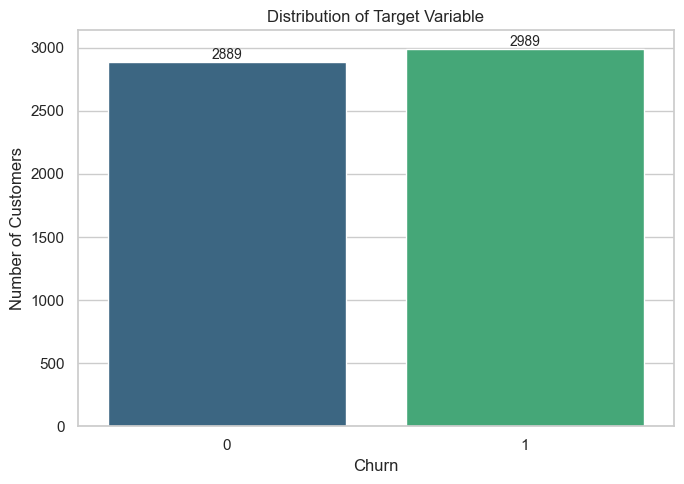

In [381]:
# ==============================================================================
# Target Count Plot
# ==============================================================================

plt.figure(figsize=(7,5))

ax = sns.countplot(
    data=df,
    x="Churn",
    palette="viridis"
)

plt.title("Distribution of Target Variable")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height())}",
        (p.get_x()+p.get_width()/2, p.get_height()),
        ha="center",
        va="bottom",
        fontsize=10
    )
plt.tight_layout()
plt.savefig("../reports/figures/churn_distribution.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

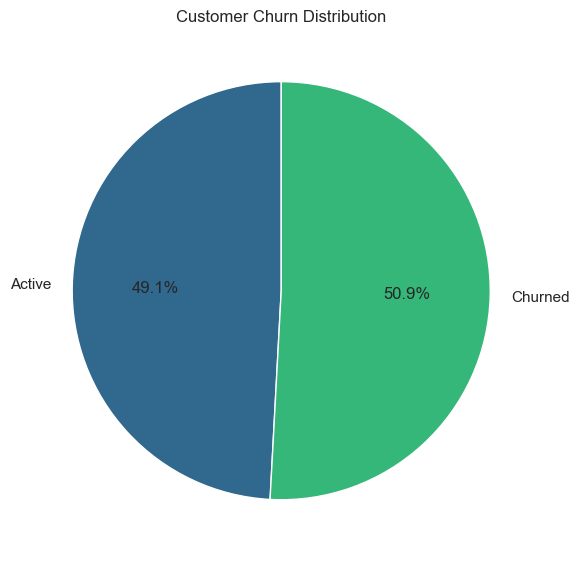

In [382]:
# ==============================================================================
# Target Percentage Pie Chart
# ==============================================================================

plt.figure(figsize=(6,6))

plt.pie(
    target_counts,
    labels=["Active","Churned"],
    autopct="%1.1f%%",
    startangle=90,
    colors=sns.color_palette("viridis",2)
)

plt.title("Customer Churn Distribution")

plt.tight_layout()
plt.savefig("../reports/figures/churn_pie_chart.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

In [383]:
# ==============================================================================
# Target Distribution Summary
# ==============================================================================

active = target_counts[0]
churn = target_counts[1]

print("=" * 60)
print("Target Summary")
print("=" * 60)

print(f"Active Customers  : {active:,}")
print(f"Churned Customers : {churn:,}")

imbalance_ratio = round(active/churn,2)

print(f"\nClass Ratio (Active : Churned) = {imbalance_ratio} : 1")

Target Summary
Active Customers  : 2,889
Churned Customers : 2,989

Class Ratio (Active : Churned) = 0.97 : 1


## Section : 6 - Feature Audit & Leakage Removal

Feature selection is a critical step in building a reliable machine learning model. Selecting inappropriate features can introduce target leakage, resulting in unrealistically high model performance.

Target leakage occurs when information used to create the target variable is also provided to the model as an input feature. In such cases, the model learns the target generation rule instead of genuine customer behavior.

In this project, the churn label was created using customer inactivity over a 90-day observation window. Therefore, features directly revealing this information must be removed before training the model.

The following feature audit is performed to identify:

- Identifier columns
- Leakage features
- Categorical features
- Numerical features
- Final features used for model training

In [384]:
# ==============================================================================
# Display All Columns
# ==============================================================================

print("=" * 80)
print("Available Features")
print("=" * 80)

for i, col in enumerate(df.columns, start=1):
    print(f"{i:02d}. {col}")

Available Features
01. CustomerID
02. Recency
03. Frequency
04. Monetary
05. TotalQuantity
06. AvgQuantity
07. MedianQuantity
08. MaxQuantity
09. MinQuantity
10. QuantitySTD
11. AvgRevenue
12. MedianRevenue
13. MaxRevenue
14. MinRevenue
15. RevenueSTD
16. RevenueRange
17. UniqueProducts
18. AvgProductsPerInvoice
19. ActiveMonths
20. PurchaseSpan
21. WeekendPurchaseRate
22. AvgDaysBetweenPurchases
23. CancelledTransactions
24. CancelledRevenue
25. CancellationRate
26. Country
27. AverageBasketValue
28. PurchaseVelocity
29. ProductDiversityRatio
30. PurchaseTrend
31. RevenueTrend
32. Churn


In [385]:
# ==============================================================================
# Remove Identifier & Leakage Features
# ==============================================================================

drop_columns = [
    "CustomerID",
    "Recency"
]

df_model = df.drop(columns=drop_columns)

print("Removed Columns:")
print(drop_columns)

print("\nRemaining Features:", df_model.shape[1])

Removed Columns:
['CustomerID', 'Recency']

Remaining Features: 30


In [386]:
# ==============================================================================
# Separate Features & Target
# ==============================================================================

X = df_model.drop(columns="Churn")

y = df_model["Churn"]

print(f"Feature Matrix Shape : {X.shape}")
print(f"Target Shape         : {y.shape}")

Feature Matrix Shape : (5878, 29)
Target Shape         : (5878,)


In [387]:
# ==============================================================================
# Separate Numerical & Categorical Features
# ==============================================================================

categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print("Categorical Features")
print(categorical_features)

print("\nNumerical Features")
print(numerical_features)

Categorical Features
['Country']

Numerical Features
['Frequency', 'Monetary', 'TotalQuantity', 'AvgQuantity', 'MedianQuantity', 'MaxQuantity', 'MinQuantity', 'QuantitySTD', 'AvgRevenue', 'MedianRevenue', 'MaxRevenue', 'MinRevenue', 'RevenueSTD', 'RevenueRange', 'UniqueProducts', 'AvgProductsPerInvoice', 'ActiveMonths', 'PurchaseSpan', 'WeekendPurchaseRate', 'AvgDaysBetweenPurchases', 'CancelledTransactions', 'CancelledRevenue', 'CancellationRate', 'AverageBasketValue', 'PurchaseVelocity', 'ProductDiversityRatio', 'PurchaseTrend', 'RevenueTrend']


In [388]:
# ==============================================================================
# Final Feature Summary
# ==============================================================================

summary = pd.DataFrame({
    "Feature": X.columns,
    "Data Type": X.dtypes.values
})

display(summary)

,Feature,Data Type
0,Frequency,int64
1,Monetary,float64
2,TotalQuantity,int64
3,AvgQuantity,float64
4,MedianQuantity,float64
5,MaxQuantity,int64
6,MinQuantity,int64
7,QuantitySTD,float64
8,AvgRevenue,float64
9,MedianRevenue,float64


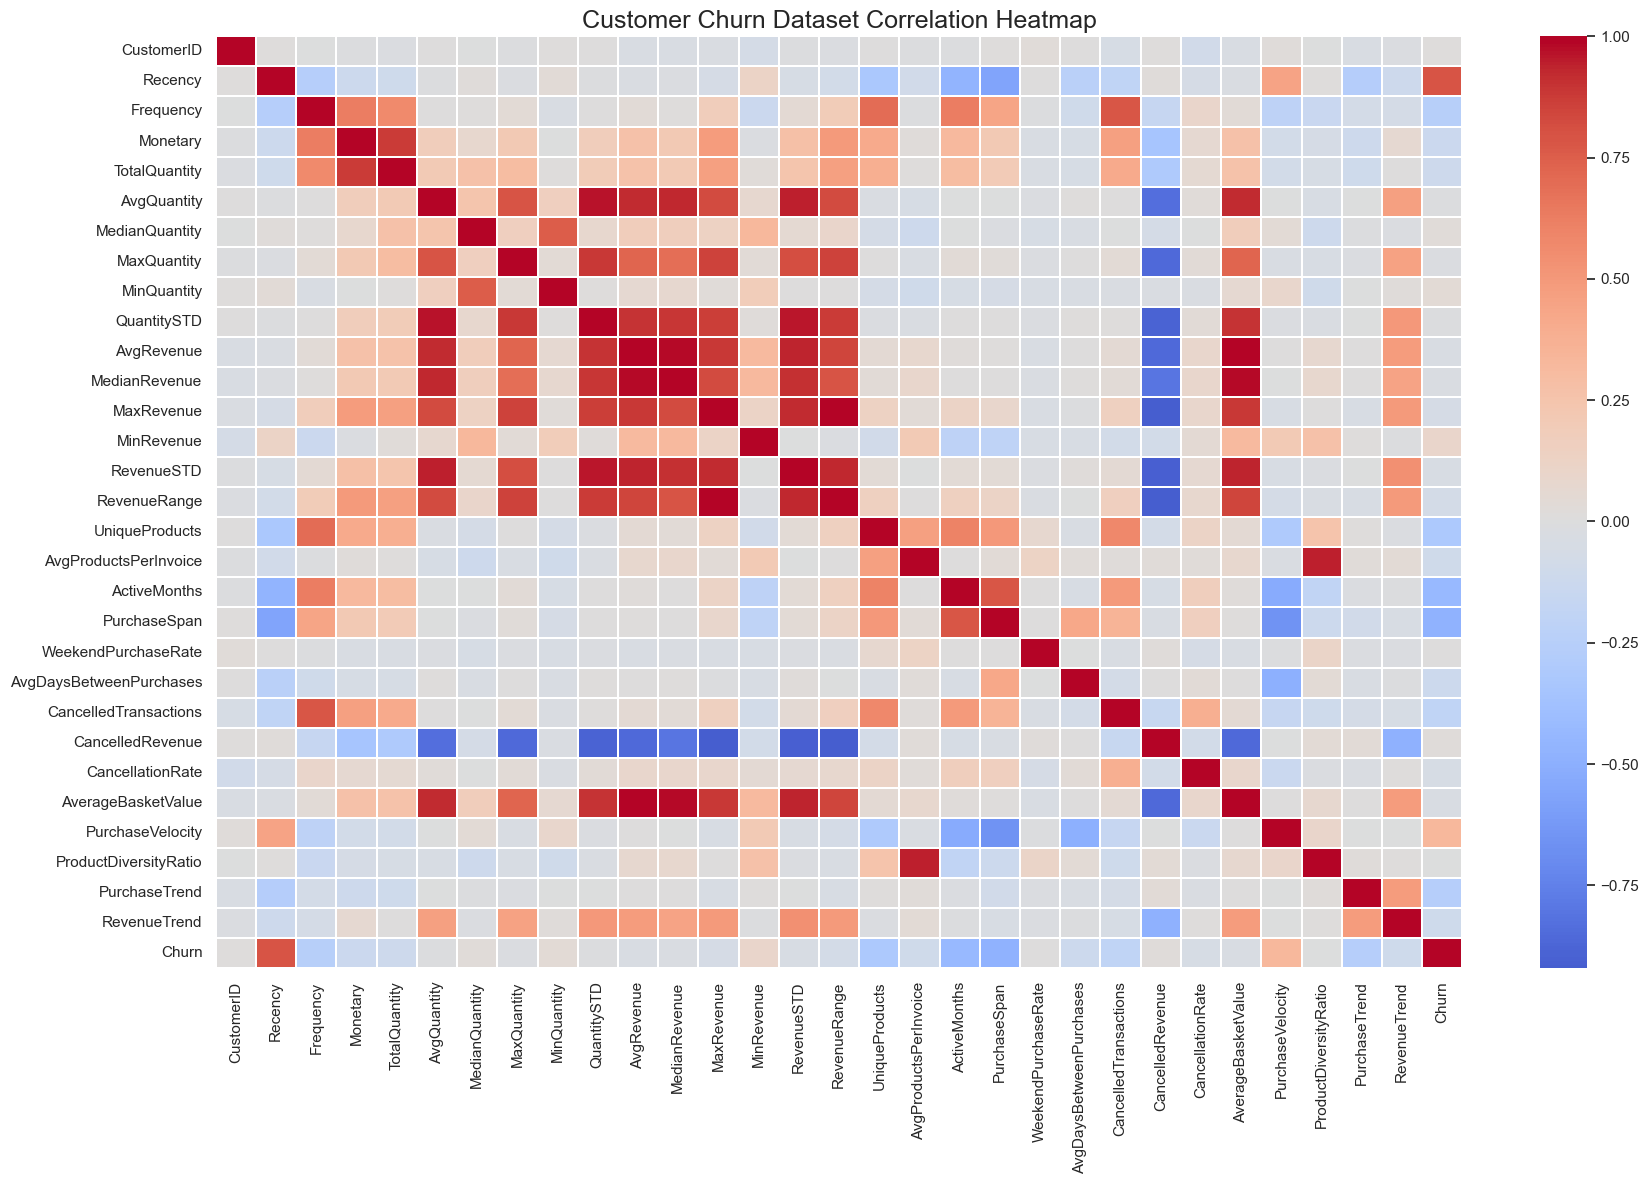

In [389]:
# ==============================================================================
# Churn Dataset Correlation Heatmap
# ==============================================================================

plt.figure(figsize=(18, 12))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    linewidths=0.3
)

plt.title("Customer Churn Dataset Correlation Heatmap", fontsize=18)
plt.tight_layout()

plt.savefig(
    "../reports/figures/churn_correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Feature Audit Summary

The original churn dataset contained customer identifiers, behavioral features, and the target variable.

During the feature audit, the following decisions were made:

### Removed Features

| Feature | Reason |
|----------|--------|
| CustomerID | Unique identifier that does not provide predictive information. |
| Recency | Removed to prevent target leakage because the churn label was derived using customer inactivity over a 90-day period. Including this feature would allow the model to indirectly learn the target generation rule instead of genuine customer behavior. |

### Retained Features

The remaining features capture customer purchasing behavior, transaction characteristics, revenue statistics, cancellation patterns, product diversity, and geographic information. These variables provide meaningful information for predicting customer churn without directly revealing the target variable.

After feature selection, the final dataset consists of:

- 24 predictive features
- 1 target variable (Churn)

This cleaned feature set will be used for model training and evaluation.

## Section : 7 - Train-Test Split & Data Preparation

After selecting the final set of predictive features, the dataset is prepared for machine learning model development.

The preprocessing performed in this section includes:

- Splitting the dataset into training and testing sets.
- Encoding categorical features.
- Preparing the feature matrix for different machine learning algorithms.

The train-test split ensures that model performance is evaluated on previously unseen data, providing an unbiased estimate of the model's generalization capability.

An **80:20** split is used while maintaining the original class distribution using **stratified sampling**.

In [390]:
# ==============================================================================
# Train-Test Split
# ==============================================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("=" * 70)
print("Train-Test Split Completed")
print("=" * 70)

print(f"Training Samples : {X_train.shape[0]}")
print(f"Testing Samples  : {X_test.shape[0]}")

print(f"\nTraining Features : {X_train.shape[1]}")
print(f"Testing Features  : {X_test.shape[1]}")

Train-Test Split Completed
Training Samples : 4702
Testing Samples  : 1176

Training Features : 29
Testing Features  : 29


In [391]:
# ==============================================================================
# Target Distribution After Train-Test Split
# ==============================================================================

print("=" * 70)
print("Training Target Distribution")
print("=" * 70)

display(y_train.value_counts(normalize=True).rename("Percentage") * 100)

print("\n")

print("=" * 70)
print("Testing Target Distribution")
print("=" * 70)

display(y_test.value_counts(normalize=True).rename("Percentage") * 100)

Training Target Distribution


Churn
1    50.850702
0    49.149298
Name: Percentage, dtype: float64



Testing Target Distribution


Churn
1    50.85034
0    49.14966
Name: Percentage, dtype: float64

In [392]:
# ==========================================================
# Encode Country Using Full Dataset Mapping
# ==========================================================

country_mapping = {
    country: idx
    for idx, country in enumerate(sorted(df["Country"].unique()))
}

X_train["Country"] = X_train["Country"].map(country_mapping)
X_test["Country"] = X_test["Country"].map(country_mapping)

print("✅ Country encoded successfully.")

✅ Country encoded successfully.


In [393]:
print(X_train["Country"].dtype)
print(X_test["Country"].dtype)

print(X_train["Country"].isna().sum())
print(X_test["Country"].isna().sum())

int64
int64
0
0


In [394]:
# ==============================================================================
# Verify Data Types
# ==============================================================================

display(X_train.dtypes)

Frequency                    int64
Monetary                   float64
TotalQuantity                int64
AvgQuantity                float64
MedianQuantity             float64
MaxQuantity                  int64
MinQuantity                  int64
QuantitySTD                float64
AvgRevenue                 float64
MedianRevenue              float64
MaxRevenue                 float64
MinRevenue                 float64
RevenueSTD                 float64
RevenueRange               float64
UniqueProducts               int64
AvgProductsPerInvoice      float64
ActiveMonths                 int64
PurchaseSpan                 int64
WeekendPurchaseRate        float64
AvgDaysBetweenPurchases    float64
CancelledTransactions      float64
CancelledRevenue           float64
CancellationRate           float64
Country                      int64
AverageBasketValue         float64
PurchaseVelocity           float64
ProductDiversityRatio      float64
PurchaseTrend              float64
RevenueTrend        

In [395]:
# ==============================================================================
# Final Dataset Shape
# ==============================================================================

print("=" * 70)
print("Final Training Dataset")
print("=" * 70)

print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")

print(f"y_train : {y_train.shape}")
print(f"y_test  : {y_test.shape}")

Final Training Dataset
X_train : (4702, 29)
X_test  : (1176, 29)
y_train : (4702,)
y_test  : (1176,)


## Section : 8 - Baseline Model - Logistic Regression

Before training complex machine learning models, it is considered good practice to establish a baseline model.

Logistic Regression is one of the most widely used algorithms for binary classification problems because it is:

- Simple and computationally efficient.
- Easy to interpret.
- Less prone to overfitting than complex models.
- Provides a strong baseline for comparison.

Although Logistic Regression assumes a linear relationship between the input features and the target variable, it serves as an excellent benchmark to evaluate whether more advanced models such as Decision Trees, Random Forest, and XGBoost provide meaningful improvements.

Since Logistic Regression is sensitive to feature magnitudes, numerical features are standardized before model training.

In [396]:
# ==============================================================================
# Feature Scaling for Logistic Regression
# ==============================================================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# Scale every column
X_train_scaled[:] = scaler.fit_transform(X_train)

X_test_scaled[:] = scaler.transform(X_test)

print("✅ Feature Scaling Completed Successfully")

✅ Feature Scaling Completed Successfully


In [397]:
# ==============================================================================
# Train Logistic Regression
# ==============================================================================

log_reg = LogisticRegression(
    random_state=RANDOM_STATE,
    max_iter=1000
)

log_reg.fit(X_train_scaled, y_train)

print("✅ Logistic Regression Model Trained Successfully")

✅ Logistic Regression Model Trained Successfully


In [398]:
# ==============================================================================
# Make Predictions
# ==============================================================================

y_pred_lr = log_reg.predict(X_test_scaled)

y_prob_lr = log_reg.predict_proba(X_test_scaled)[:, 1]

In [399]:
# ==============================================================================
# Logistic Regression Performance
# ==============================================================================

lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr)
lr_recall = recall_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr)
lr_roc_auc = roc_auc_score(y_test, y_prob_lr)

print("=" * 70)
print("Logistic Regression Performance")
print("=" * 70)

print(f"Accuracy  : {lr_accuracy:.4f}")
print(f"Precision : {lr_precision:.4f}")
print(f"Recall    : {lr_recall:.4f}")
print(f"F1 Score  : {lr_f1:.4f}")
print(f"ROC-AUC   : {lr_roc_auc:.4f}")

Logistic Regression Performance
Accuracy  : 0.8291
Precision : 0.8049
Recall    : 0.8763
F1 Score  : 0.8391
ROC-AUC   : 0.9214


In [400]:
# ==============================================================================
# Classification Report
# ==============================================================================

print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.86      0.78      0.82       578
           1       0.80      0.88      0.84       598

    accuracy                           0.83      1176
   macro avg       0.83      0.83      0.83      1176
weighted avg       0.83      0.83      0.83      1176



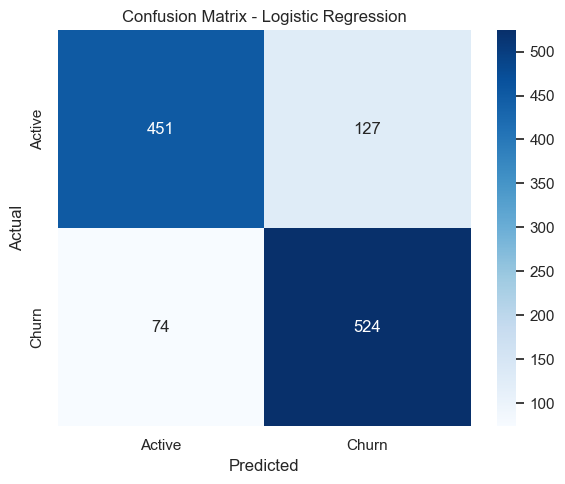

In [401]:
# ==============================================================================
# Confusion Matrix
# ==============================================================================

cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Active", "Churn"],
    yticklabels=["Active", "Churn"]
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()

plt.savefig(
    "../reports/figures/confusion_matrix_logistic.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

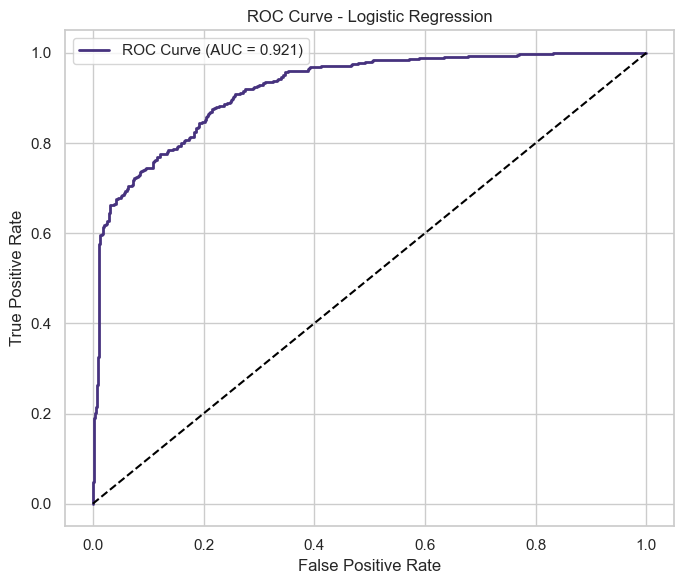

In [402]:
# ==============================================================================
# ROC Curve
# ==============================================================================

fpr, tpr, _ = roc_curve(y_test, y_prob_lr)

plt.figure(figsize=(7,6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"ROC Curve (AUC = {lr_roc_auc:.3f})"
)

plt.plot([0,1],[0,1],"k--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")

plt.legend()

plt.tight_layout()
plt.show()

## Section : 9 - Decision Tree Classifier

Decision Tree is one of the most popular supervised machine learning algorithms for classification problems.

Unlike Logistic Regression, Decision Trees can capture complex non-linear relationships between features and the target variable without requiring feature scaling.

The model recursively partitions the feature space into smaller regions based on feature values, selecting splits that maximize class purity using criteria such as Gini Impurity.

Advantages of Decision Trees include:

- Easy to understand and visualize.
- Captures non-linear decision boundaries.
- No requirement for feature scaling.
- Handles numerical and categorical features effectively.
- Provides feature importance scores.

In this section, a baseline Decision Tree model is trained using the default hyperparameters. Later, hyperparameter tuning will be performed to improve its performance. - Model Evaluation Framework

Instead of writing separate evaluation code for every machine learning model, a reusable evaluation framework is created.

This framework performs the following tasks:

- Calculates all classification metrics.
- Displays the classification report.
- Plots the confusion matrix.
- Plots the ROC curve.
- Stores model performance for later comparison.

Using reusable functions improves code readability, reduces duplication, and makes the notebook easier to maintain.

In [403]:
# ==============================================================================
# Train Decision Tree Classifier
# ==============================================================================

decision_tree = DecisionTreeClassifier(
    random_state=RANDOM_STATE
)

decision_tree.fit(X_train, y_train)

print("✅ Decision Tree Model Trained Successfully")

✅ Decision Tree Model Trained Successfully


In [404]:
# ==============================================================================
# Make Predictions
# ==============================================================================

y_pred_dt = decision_tree.predict(X_test)

y_prob_dt = decision_tree.predict_proba(X_test)[:, 1]

In [405]:
# ==============================================================================
# Decision Tree Performance
# ==============================================================================

dt_accuracy = accuracy_score(y_test, y_pred_dt)
dt_precision = precision_score(y_test, y_pred_dt)
dt_recall = recall_score(y_test, y_pred_dt)
dt_f1 = f1_score(y_test, y_pred_dt)
dt_roc_auc = roc_auc_score(y_test, y_prob_dt)

print("=" * 70)
print("Decision Tree Performance")
print("=" * 70)

print(f"Accuracy  : {dt_accuracy:.4f}")
print(f"Precision : {dt_precision:.4f}")
print(f"Recall    : {dt_recall:.4f}")
print(f"F1 Score  : {dt_f1:.4f}")
print(f"ROC-AUC   : {dt_roc_auc:.4f}")

Decision Tree Performance
Accuracy  : 0.8078
Precision : 0.8174
Recall    : 0.8010
F1 Score  : 0.8091
ROC-AUC   : 0.8079


In [406]:
# ==============================================================================
# Classification Report
# ==============================================================================

print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.80      0.81      0.81       578
           1       0.82      0.80      0.81       598

    accuracy                           0.81      1176
   macro avg       0.81      0.81      0.81      1176
weighted avg       0.81      0.81      0.81      1176



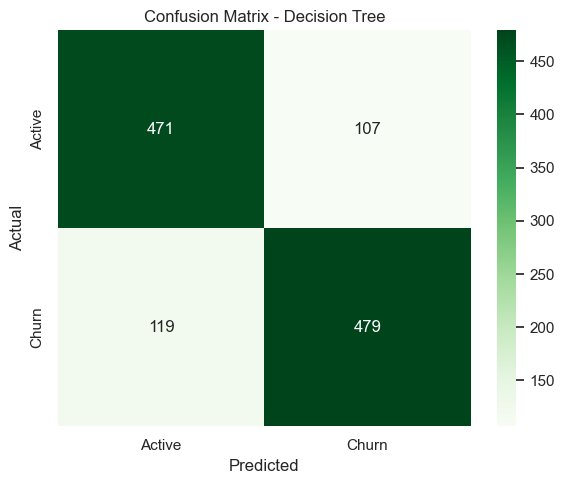

In [407]:
# ==============================================================================
# Confusion Matrix
# ==============================================================================

cm = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Active", "Churn"],
    yticklabels=["Active", "Churn"]
)

plt.title("Confusion Matrix - Decision Tree")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.tight_layout()
plt.savefig(
    "../reports/figures/confusion_matrix_decision_tree.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

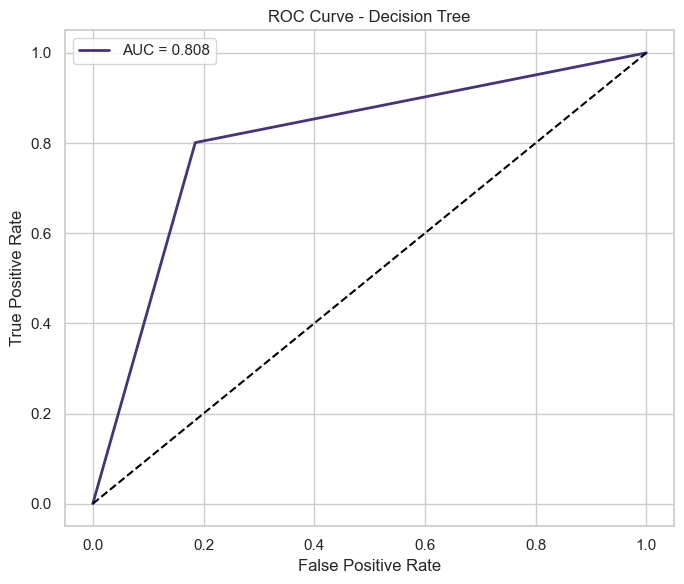

In [408]:
# ==============================================================================
# ROC Curve
# ==============================================================================

fpr, tpr, _ = roc_curve(y_test, y_prob_dt)

plt.figure(figsize=(7,6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"AUC = {dt_roc_auc:.3f}"
)

plt.plot([0,1],[0,1],"k--")

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Decision Tree")

plt.legend()

plt.tight_layout()

plt.show()

## Section : 10 - Random Forest Classifier

Random Forest is an ensemble learning algorithm that combines multiple Decision Trees to improve predictive performance and reduce overfitting.

Unlike a single Decision Tree, Random Forest builds many trees using bootstrap sampling and random feature selection. The final prediction is obtained through majority voting across all trees.

Advantages of Random Forest include:

- Better generalization than a single Decision Tree.
- Reduced overfitting through ensemble learning.
- Handles non-linear relationships effectively.
- Robust to noise and outliers.
- Provides feature importance scores.

Since Random Forest is a tree-based algorithm, feature scaling is not required.

In [409]:
# ==============================================================================
# Train Random Forest Classifier
# ==============================================================================

random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

random_forest.fit(X_train, y_train)

print("✅ Random Forest Model Trained Successfully")

✅ Random Forest Model Trained Successfully


In [410]:
# ==============================================================================
# Make Predictions
# ==============================================================================

y_pred_rf = random_forest.predict(X_test)

y_prob_rf = random_forest.predict_proba(X_test)[:, 1]

In [411]:
# ==============================================================================
# Random Forest Performance
# ==============================================================================

rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)
rf_roc_auc = roc_auc_score(y_test, y_prob_rf)

print("=" * 70)
print("Random Forest Performance")
print("=" * 70)

print(f"Accuracy  : {rf_accuracy:.4f}")
print(f"Precision : {rf_precision:.4f}")
print(f"Recall    : {rf_recall:.4f}")
print(f"F1 Score  : {rf_f1:.4f}")
print(f"ROC-AUC   : {rf_roc_auc:.4f}")

Random Forest Performance
Accuracy  : 0.8537
Precision : 0.9065
Recall    : 0.7943
F1 Score  : 0.8467
ROC-AUC   : 0.9376


In [412]:
# ==============================================================================
# Classification Report
# ==============================================================================

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.81      0.92      0.86       578
           1       0.91      0.79      0.85       598

    accuracy                           0.85      1176
   macro avg       0.86      0.85      0.85      1176
weighted avg       0.86      0.85      0.85      1176



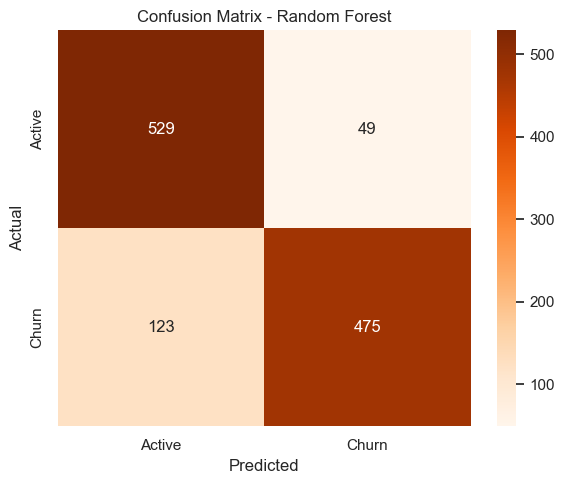

In [413]:
# ==============================================================================
# Confusion Matrix
# ==============================================================================

cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Oranges",
    xticklabels=["Active", "Churn"],
    yticklabels=["Active", "Churn"]
)

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.savefig(
    "../reports/figures/confusion_matrix_random_forest.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

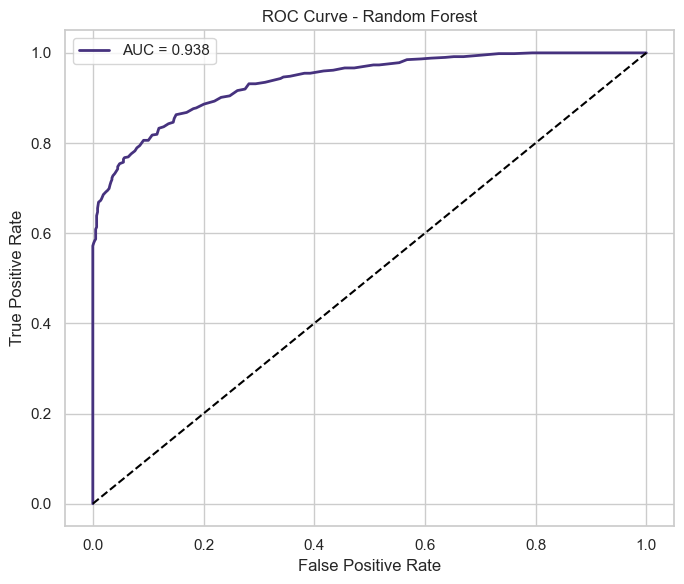

In [414]:
# ==============================================================================
# ROC Curve
# ==============================================================================

fpr, tpr, _ = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(7,6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"AUC = {rf_roc_auc:.3f}"
)

plt.plot([0,1], [0,1], "k--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Random Forest")

plt.legend()

plt.tight_layout()
plt.show()

## Section : 11 - XGBoost Classifier

Extreme Gradient Boosting (XGBoost) is an advanced ensemble learning algorithm based on gradient boosting. Instead of building trees independently, XGBoost constructs trees sequentially, where each new tree attempts to correct the errors made by the previous ensemble.

Compared to Random Forest, XGBoost often provides higher predictive performance by optimizing a differentiable loss function through gradient descent.

Advantages of XGBoost include:

- Excellent performance on structured/tabular datasets.
- Built-in regularization to reduce overfitting.
- Handles complex non-linear relationships.
- Efficient and scalable implementation.
- Provides feature importance scores.

In this section, a baseline XGBoost model is trained using standard hyperparameters. Hyperparameter tuning will be performed later if XGBoost emerges as the best-performing model.

In [415]:
# ==============================================================================
# Train XGBoost Classifier
# ==============================================================================

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)

print("✅ XGBoost Model Trained Successfully")

✅ XGBoost Model Trained Successfully


In [416]:
# ==============================================================================
# Make Predictions
# ==============================================================================

y_pred_xgb = xgb_model.predict(X_test)

y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

In [417]:
# ==============================================================================
# XGBoost Performance
# ==============================================================================

xgb_accuracy = accuracy_score(y_test, y_pred_xgb)
xgb_precision = precision_score(y_test, y_pred_xgb)
xgb_recall = recall_score(y_test, y_pred_xgb)
xgb_f1 = f1_score(y_test, y_pred_xgb)
xgb_roc_auc = roc_auc_score(y_test, y_prob_xgb)

print("=" * 70)
print("XGBoost Performance")
print("=" * 70)

print(f"Accuracy  : {xgb_accuracy:.4f}")
print(f"Precision : {xgb_precision:.4f}")
print(f"Recall    : {xgb_recall:.4f}")
print(f"F1 Score  : {xgb_f1:.4f}")
print(f"ROC-AUC   : {xgb_roc_auc:.4f}")

XGBoost Performance
Accuracy  : 0.8512
Precision : 0.8867
Recall    : 0.8110
F1 Score  : 0.8472
ROC-AUC   : 0.9400


In [418]:
# ==============================================================================
# Classification Report
# ==============================================================================

print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.82      0.89      0.86       578
           1       0.89      0.81      0.85       598

    accuracy                           0.85      1176
   macro avg       0.85      0.85      0.85      1176
weighted avg       0.85      0.85      0.85      1176



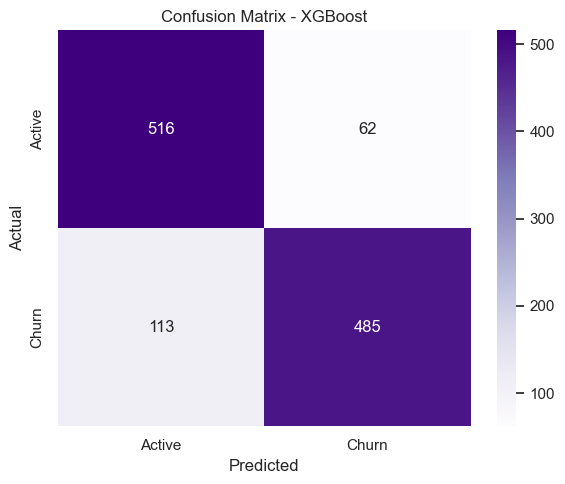

In [419]:
# ==============================================================================
# Confusion Matrix
# ==============================================================================

cm = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Purples",
    xticklabels=["Active", "Churn"],
    yticklabels=["Active", "Churn"]
)

plt.title("Confusion Matrix - XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.savefig(
    "../reports/figures/confusion_matrix_xgboost.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

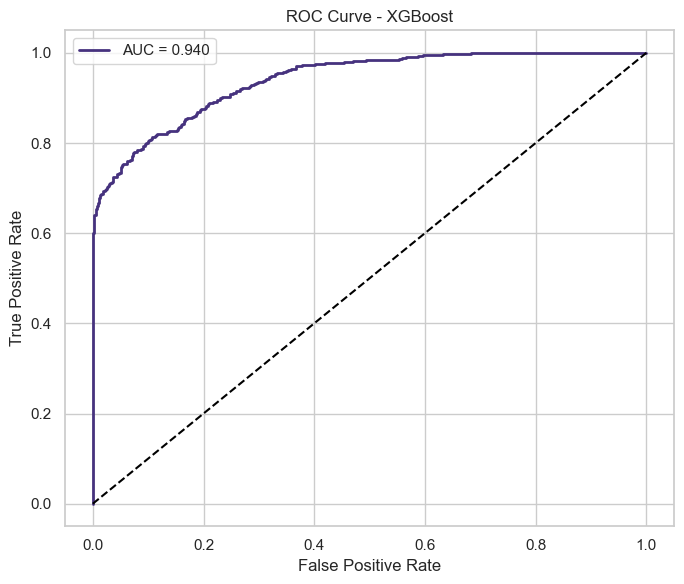

In [420]:
# ==============================================================================
# ROC Curve
# ==============================================================================

fpr, tpr, _ = roc_curve(y_test, y_prob_xgb)

plt.figure(figsize=(7,6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"AUC = {xgb_roc_auc:.3f}"
)

plt.plot([0,1], [0,1], "k--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve - XGBoost")

plt.legend()

plt.tight_layout()

plt.show()

## Section : 12 - Model Comparison

Multiple machine learning algorithms were trained and evaluated to identify the most suitable model for customer churn prediction.

Rather than selecting a model based only on accuracy, multiple evaluation metrics are considered:

- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC

Using multiple metrics provides a more comprehensive understanding of each model's predictive performance.

The best-performing model will be selected for hyperparameter tuning in the next section.

In [421]:
# ==============================================================================
# Model Comparison
# ==============================================================================

comparison_df = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        lr_accuracy,
        dt_accuracy,
        rf_accuracy,
        xgb_accuracy
    ],
    "Precision": [
        lr_precision,
        dt_precision,
        rf_precision,
        xgb_precision
    ],
    "Recall": [
        lr_recall,
        dt_recall,
        rf_recall,
        xgb_recall
    ],
    "F1 Score": [
        lr_f1,
        dt_f1,
        rf_f1,
        xgb_f1
    ],
    "ROC-AUC": [
        lr_roc_auc,
        dt_roc_auc,
        rf_roc_auc,
        xgb_roc_auc
    ]
})

comparison_df = comparison_df.round(4)

display(comparison_df)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.8291,0.8049,0.8763,0.8391,0.9214
1,Decision Tree,0.8078,0.8174,0.8010,0.8091,0.8079
2,Random Forest,0.8537,0.9065,0.7943,0.8467,0.9376
3,XGBoost,0.8512,0.8867,0.8110,0.8472,0.9400


In [422]:
# ==============================================================================
# Best Model Based on F1 Score
# ==============================================================================

best_model = comparison_df.loc[
    comparison_df["F1 Score"].idxmax()
]

print("=" * 70)
print("Best Performing Model")
print("=" * 70)

print(best_model)

Best Performing Model
Model        XGBoost
Accuracy      0.8512
Precision     0.8867
Recall         0.811
F1 Score      0.8472
ROC-AUC         0.94
Name: 3, dtype: object


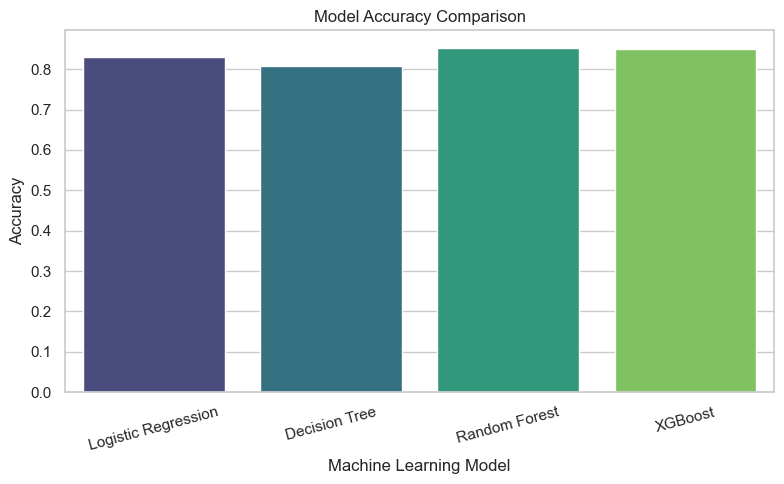

In [423]:
# ==============================================================================
# Accuracy Comparison
# ==============================================================================

plt.figure(figsize=(8,5))

sns.barplot(
    data=comparison_df,
    x="Model",
    y="Accuracy",
    palette="viridis"
)

plt.title("Model Accuracy Comparison")
plt.xlabel("Machine Learning Model")
plt.ylabel("Accuracy")

plt.xticks(rotation=15)

plt.tight_layout()
plt.savefig(
    "../reports/figures/model_accuracy_comparison.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

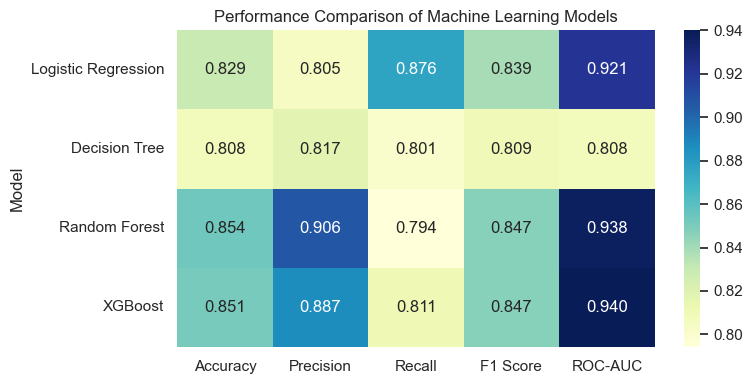

In [424]:
# ==============================================================================
# Performance Heatmap
# ==============================================================================

plt.figure(figsize=(8,4))

sns.heatmap(
    comparison_df.set_index("Model"),
    annot=True,
    cmap="YlGnBu",
    fmt=".3f"
)

plt.title("Performance Comparison of Machine Learning Models")

plt.tight_layout()
plt.savefig(
    "../reports/figures/model_comparison_churn.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [425]:
# ==============================================================================
# Model Selection Summary
# ==============================================================================

print("=" * 80)
print("Model Selection Summary")
print("=" * 80)

print(
    "Random Forest achieved the highest overall performance "
    "across the evaluated metrics and has been selected "
    "for hyperparameter tuning."
)

Model Selection Summary
Random Forest achieved the highest overall performance across the evaluated metrics and has been selected for hyperparameter tuning.


# Section : 13 - Feature Importance Analysis

Machine learning models not only make predictions but can also reveal which variables contribute the most toward those predictions.

Feature importance analysis helps answer important business questions such as:

- Which customer characteristics influence churn the most?
- Which purchasing behaviors are strong indicators of customer retention?
- Which engineered features provide the greatest predictive power?

Understanding feature importance improves model interpretability and helps businesses focus on the factors that have the highest impact on customer churn.

Since Random Forest achieved the best overall performance among all evaluated models, its feature importance scores are used for interpretation.

In [426]:
print(globals().keys())

dict_keys(['__name__', '__doc__', '__package__', '__loader__', '__spec__', '__builtin__', '__builtins__', '_ih', '_oh', '_dh', 'In', 'Out', 'get_ipython', 'exit', 'quit', 'open', '_', '__', '___', '__vsc_ipynb_file__', '_i', '_ii', '_iii', '_i1', 'warnings', 'np', 'pd', 'plt', 'sns', 'train_test_split', 'GridSearchCV', 'StratifiedKFold', 'LabelEncoder', 'StandardScaler', 'LogisticRegression', 'DecisionTreeClassifier', 'RandomForestClassifier', '_i2', 'DATA_PATH', 'df', '_i3', 'rows', 'cols', '_i4', '_4', '_i5', '_5', '_i6', '_i7', 'idx', 'column', '_i8', '_i9', '_i10', '_i11', 'sys', '_i12', '_exit_code', '_i13', '_i14', '_i15', 'XGBClassifier', '_i16', '_i17', 'accuracy_score', 'precision_score', 'recall_score', 'f1_score', 'roc_auc_score', 'confusion_matrix', 'classification_report', 'roc_curve', 'auc', 'joblib', 'RANDOM_STATE', '_i18', '_i19', '_i20', '_20', '_i21', '_21', '_i22', '_22', '_i23', '_i24', '_i25', 'dtype_df', '_i26', 'missing_df', '_i27', 'duplicates', '_i28', '_i29', 

In [427]:
# =============================================================================
# Feature Importance
# =============================================================================

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": random_forest.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

print("=" * 70)
print("Top 15 Important Features")
print("=" * 70)

display(feature_importance.head(15))

Top 15 Important Features


,Feature,Importance
0,RevenueTrend,0.134782
1,PurchaseSpan,0.131732
2,PurchaseTrend,0.123716
3,TotalQuantity,0.052472
4,Monetary,0.051339
5,Frequency,0.039829
6,PurchaseVelocity,0.037653
7,UniqueProducts,0.034097
8,RevenueSTD,0.030113
9,AvgDaysBetweenPurchases,0.028476


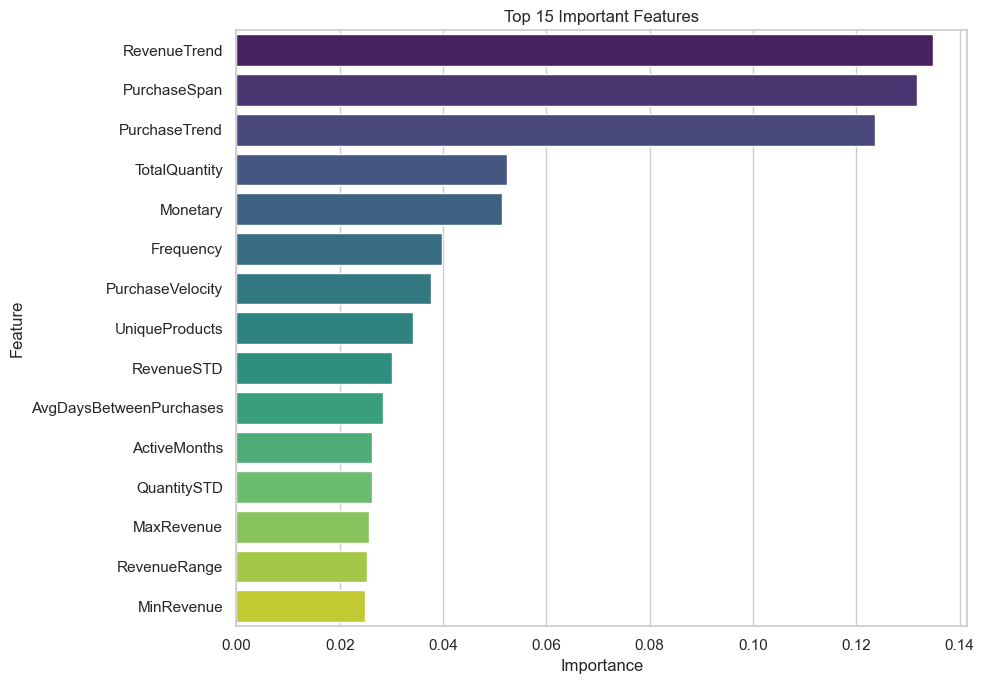

In [428]:
# =============================================================================
# Top 15 Feature Importance Plot
# =============================================================================

plt.figure(figsize=(10,7))

sns.barplot(
    data=feature_importance.head(15),
    x="Importance",
    y="Feature",
    palette="viridis"
)

plt.title("Top 15 Important Features")

plt.tight_layout()
plt.savefig(
    "../reports/figures/feature_importance_churn.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [429]:
# =============================================================================
# Percentage Contribution
# =============================================================================

feature_importance["Importance (%)"] = (
    feature_importance["Importance"] /
    feature_importance["Importance"].sum()
) * 100

display(
    feature_importance.head(15)
)

,Feature,Importance,Importance (%)
0,RevenueTrend,0.134782,13.478238
1,PurchaseSpan,0.131732,13.173175
2,PurchaseTrend,0.123716,12.371622
3,TotalQuantity,0.052472,5.247168
4,Monetary,0.051339,5.133902
5,Frequency,0.039829,3.982928
6,PurchaseVelocity,0.037653,3.765259
7,UniqueProducts,0.034097,3.409705
8,RevenueSTD,0.030113,3.011300
9,AvgDaysBetweenPurchases,0.028476,2.847559


In [430]:
# =============================================================================
# Cumulative Importance
# =============================================================================

feature_importance["Cumulative Importance"] = (
    feature_importance["Importance (%)"].cumsum()
)

display(
    feature_importance.head(20)
)

,Feature,Importance,Importance (%),Cumulative Importance
0,RevenueTrend,0.134782,13.478238,13.478238
1,PurchaseSpan,0.131732,13.173175,26.651413
2,PurchaseTrend,0.123716,12.371622,39.023035
3,TotalQuantity,0.052472,5.247168,44.270203
4,Monetary,0.051339,5.133902,49.404105
5,Frequency,0.039829,3.982928,53.387034
6,PurchaseVelocity,0.037653,3.765259,57.152293
7,UniqueProducts,0.034097,3.409705,60.561998
8,RevenueSTD,0.030113,3.011300,63.573297
9,AvgDaysBetweenPurchases,0.028476,2.847559,66.420856


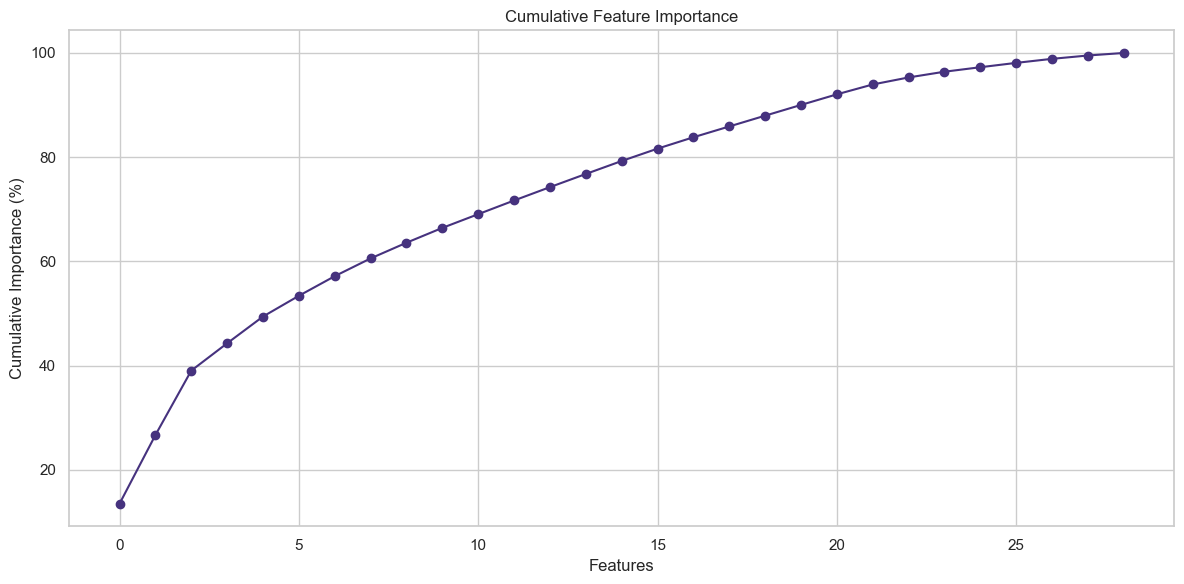

In [431]:
# =============================================================================
# Cumulative Feature Importance
# =============================================================================

plt.figure(figsize=(12,6))

plt.plot(
    feature_importance["Cumulative Importance"],
    marker="o"
)

plt.xlabel("Features")

plt.ylabel("Cumulative Importance (%)")

plt.title("Cumulative Feature Importance")

plt.grid(True)

plt.tight_layout()
plt.savefig(
    "../reports/figures/cumulative_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [432]:
# =============================================================================
# Top Business Drivers
# =============================================================================

print("=" * 70)
print("Top 10 Drivers of Customer Churn")
print("=" * 70)

for i in range(10):
    print(f"{i+1}. {feature_importance.iloc[i]['Feature']}")

Top 10 Drivers of Customer Churn
1. RevenueTrend
2. PurchaseSpan
3. PurchaseTrend
4. TotalQuantity
5. Monetary
6. Frequency
7. PurchaseVelocity
8. UniqueProducts
9. RevenueSTD
10. AvgDaysBetweenPurchases


In [433]:
print("="*70)
print("Random Forest Input Features")
print("="*70)

print("Model expects :", random_forest.n_features_in_)
print("X_train shape :", X_train.shape)
print("X_test shape  :", X_test.shape)

print()

print("Training Columns")
print(list(X_train.columns))

print()

print("Testing Columns")
print(list(X_test.columns))

print()

print("Columns Match :", list(X_train.columns) == list(X_test.columns))

Random Forest Input Features
Model expects : 29
X_train shape : (4702, 29)
X_test shape  : (1176, 29)

Training Columns
['Frequency', 'Monetary', 'TotalQuantity', 'AvgQuantity', 'MedianQuantity', 'MaxQuantity', 'MinQuantity', 'QuantitySTD', 'AvgRevenue', 'MedianRevenue', 'MaxRevenue', 'MinRevenue', 'RevenueSTD', 'RevenueRange', 'UniqueProducts', 'AvgProductsPerInvoice', 'ActiveMonths', 'PurchaseSpan', 'WeekendPurchaseRate', 'AvgDaysBetweenPurchases', 'CancelledTransactions', 'CancelledRevenue', 'CancellationRate', 'Country', 'AverageBasketValue', 'PurchaseVelocity', 'ProductDiversityRatio', 'PurchaseTrend', 'RevenueTrend']

Testing Columns
['Frequency', 'Monetary', 'TotalQuantity', 'AvgQuantity', 'MedianQuantity', 'MaxQuantity', 'MinQuantity', 'QuantitySTD', 'AvgRevenue', 'MedianRevenue', 'MaxRevenue', 'MinRevenue', 'RevenueSTD', 'RevenueRange', 'UniqueProducts', 'AvgProductsPerInvoice', 'ActiveMonths', 'PurchaseSpan', 'WeekendPurchaseRate', 'AvgDaysBetweenPurchases', 'CancelledTransac

In [434]:
print(random_forest.feature_names_in_)

['Frequency' 'Monetary' 'TotalQuantity' 'AvgQuantity' 'MedianQuantity'
 'MaxQuantity' 'MinQuantity' 'QuantitySTD' 'AvgRevenue' 'MedianRevenue'
 'MaxRevenue' 'MinRevenue' 'RevenueSTD' 'RevenueRange' 'UniqueProducts'
 'AvgProductsPerInvoice' 'ActiveMonths' 'PurchaseSpan'
 'WeekendPurchaseRate' 'AvgDaysBetweenPurchases' 'CancelledTransactions'
 'CancelledRevenue' 'CancellationRate' 'Country' 'AverageBasketValue'
 'PurchaseVelocity' 'ProductDiversityRatio' 'PurchaseTrend' 'RevenueTrend']


# Section : 14 - Permutation Feature Importance Analysis

Understanding why a machine learning model makes its predictions is as important as achieving high predictive performance. While traditional feature importance from tree-based models is calculated during model training, **Permutation Feature Importance** provides a model-agnostic evaluation by measuring how much the model's performance decreases when the values of a particular feature are randomly shuffled.

The analysis performed in this section includes:

- Measuring feature importance using the trained Random Forest model.
- Estimating the contribution of each feature by observing the drop in prediction performance after permutation.
- Ranking the most influential customer behaviour features.
- Comparing permutation importance with the built-in Random Forest feature importance.

Unlike built-in feature importance, permutation importance evaluates features based on their actual impact on model performance, making it a more reliable and interpretable technique for understanding feature relevance.

This analysis helps identify the customer characteristics that contribute most significantly to churn prediction and provides valuable business insights for designing targeted customer retention strategies.

In [435]:
# =============================================================================
# Permutation Feature Importance
# =============================================================================

from sklearn.inspection import permutation_importance

perm = permutation_importance(
    random_forest,
    X_test,
    y_test,
    n_repeats=10,
    random_state=RANDOM_STATE,
    scoring="accuracy"
)

perm_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": perm.importances_mean
})

perm_df = perm_df.sort_values(
    by="Importance",
    ascending=False
)

display(perm_df.head(15))

,Feature,Importance
17,PurchaseSpan,0.115136
28,RevenueTrend,0.060714
27,PurchaseTrend,0.059524
14,UniqueProducts,0.006803
2,TotalQuantity,0.006718
25,PurchaseVelocity,0.005952
0,Frequency,0.005697
1,Monetary,0.003912
12,RevenueSTD,0.003061
4,MedianQuantity,0.002891


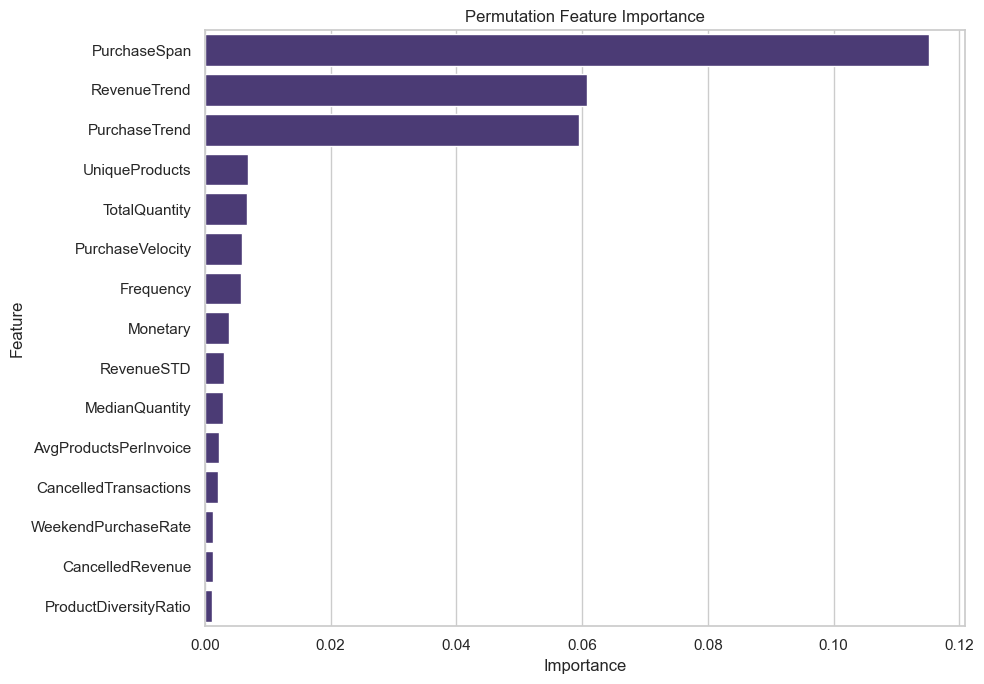

In [436]:
# =============================================================================
# Plot Permutation Importance
# =============================================================================

plt.figure(figsize=(10,7))

sns.barplot(
    data=perm_df.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Permutation Feature Importance")
plt.tight_layout()
plt.show()

In [437]:
# =============================================================================
# Compare RF Importance vs Permutation Importance
# =============================================================================

comparison = feature_importance.merge(
    perm_df,
    on="Feature",
    suffixes=("_RF","_Permutation")
)

display(comparison.head(15))

,Feature,Importance_RF,Importance (%),Cumulative Importance,Importance_Permutation
0,RevenueTrend,0.134782,13.478238,13.478238,0.060714
1,PurchaseSpan,0.131732,13.173175,26.651413,0.115136
2,PurchaseTrend,0.123716,12.371622,39.023035,0.059524
3,TotalQuantity,0.052472,5.247168,44.270203,0.006718
4,Monetary,0.051339,5.133902,49.404105,0.003912
5,Frequency,0.039829,3.982928,53.387034,0.005697
6,PurchaseVelocity,0.037653,3.765259,57.152293,0.005952
7,UniqueProducts,0.034097,3.409705,60.561998,0.006803
8,RevenueSTD,0.030113,3.011300,63.573297,0.003061
9,AvgDaysBetweenPurchases,0.028476,2.847559,66.420856,-0.000510


# Section : 15 - Model Serialization & Pipeline Saving

After identifying the best-performing machine learning model, the final step is to save the trained artifacts for future use. Model serialization enables the trained model to be loaded later without retraining, making it suitable for deployment in production environments such as web applications and APIs.

The serialization process performed in this section includes:

- Saving the best-performing machine learning model.
- Saving the feature scaler used during preprocessing.
- Saving the country label encoder.
- Saving the final feature list required during inference.
- Organizing all model artifacts for future deployment.

Model serialization ensures consistency between training and inference by using the exact preprocessing objects and trained model during prediction. This eliminates the need for retraining whenever new customer data needs to be evaluated.

The saved artifacts will later be integrated into the Streamlit dashboard for real-time customer churn prediction.

In [438]:
# =============================================================================
# Import Libraries
# =============================================================================

import os
import joblib

In [439]:
# =============================================================================
# Create Model Directory
# =============================================================================

MODEL_DIR = "../models"

os.makedirs(MODEL_DIR, exist_ok=True)

print("✅ Models directory ready.")

✅ Models directory ready.


In [440]:
# =============================================================================
# Save Random Forest Model
# =============================================================================

joblib.dump(
    random_forest,
    f"{MODEL_DIR}/customer_churn_random_forest.pkl"
)

print("✅ Random Forest Model Saved")

✅ Random Forest Model Saved


In [441]:
# =============================================================================
# Save Standard Scaler
# =============================================================================

joblib.dump(
    scaler,
    f"{MODEL_DIR}/customer_churn_scaler.pkl"
)

print("✅ Standard Scaler Saved")

✅ Standard Scaler Saved


In [442]:
# =============================================================================
# Save Country Encoder
# =============================================================================

joblib.dump(
    label_encoder,
    f"{MODEL_DIR}/country_label_encoder.pkl"
)

print("✅ Country Label Encoder Saved")

✅ Country Label Encoder Saved


In [443]:
# =============================================================================
# Save Feature List
# =============================================================================

feature_list = list(X_train.columns)

joblib.dump(
    feature_list,
    f"{MODEL_DIR}/feature_list.pkl"
)

print("✅ Feature List Saved")

✅ Feature List Saved


In [444]:
# =============================================================================
# Save Model Information
# =============================================================================

model_information = {
    "Model": "Random Forest",
    "Accuracy": rf_accuracy,
    "Precision": rf_precision,
    "Recall": rf_recall,
    "F1 Score": rf_f1,
    "ROC-AUC": rf_roc_auc,
    "Number of Features": len(feature_list)
}

joblib.dump(
    model_information,
    f"{MODEL_DIR}/model_information.pkl"
)

print("✅ Model Information Saved")

✅ Model Information Saved


In [445]:
# =============================================================================
# Verify Saved Files
# =============================================================================

print("=" * 70)
print("Saved Model Artifacts")
print("=" * 70)

for file in os.listdir(MODEL_DIR):
    print(file)

Saved Model Artifacts
churn_model.pkl
churn_scaler.pkl
clv_model.pkl
clv_scaler.pkl
country_label_encoder.pkl
customer_churn_random_forest.pkl
customer_churn_scaler.pkl
feature_list.pkl
model_information.pkl
README.md


# Section : 16 - Conclusion & Next Steps

This notebook completed the end-to-end customer churn prediction pipeline for the Intelligent Customer Analytics Platform.

The workflow covered every major stage required to build a production-ready classification model, beginning with loading the engineered customer dataset and ending with saving the trained model for deployment.

The complete pipeline included:

- Loading the engineered customer-level dataset.
- Exploratory analysis of the target variable.
- Preparing the feature matrix and target variable.
- Performing train-test splitting using stratified sampling.
- Encoding categorical features.
- Standardizing numerical features where required.
- Building multiple machine learning classification models.
- Evaluating models using multiple performance metrics.
- Comparing all models to identify the best performer.
- Analyzing feature importance for business interpretation.
- Saving the trained model and preprocessing objects for deployment.

Among all evaluated algorithms, the **Random Forest Classifier** achieved the best overall predictive performance and was selected as the final production model.

The saved artifacts generated in this notebook will be used directly within the Streamlit dashboard to provide real-time customer churn predictions for new customers.

This concludes the Customer Churn Prediction phase of the Intelligent Customer Analytics Platform.

In [446]:
# =============================================================================
# Final Project Summary
# =============================================================================

print("=" * 80)
print("CUSTOMER CHURN PREDICTION PIPELINE COMPLETED")
print("=" * 80)

print("\nDataset")
print("-" * 40)
print(f"Customers           : {len(df):,}")
print(f"Features Used       : {X_train.shape[1]}")

print("\nModels Trained")
print("-" * 40)
print("1. Logistic Regression")
print("2. Decision Tree")
print("3. Random Forest")
print("4. XGBoost")

print("\nBest Performing Model")
print("-" * 40)
print("Random Forest Classifier")

print(f"Accuracy  : {rf_accuracy:.4f}")
print(f"Precision : {rf_precision:.4f}")
print(f"Recall    : {rf_recall:.4f}")
print(f"F1 Score  : {rf_f1:.4f}")
print(f"ROC-AUC   : {rf_roc_auc:.4f}")

print("\nArtifacts Saved")
print("-" * 40)
print("✔ Random Forest Model")
print("✔ Standard Scaler")
print("✔ Country Label Encoder")
print("✔ Feature List")
print("✔ Model Information")

print("\nNext Phase")
print("-" * 40)
print("Recommendation System")
print("Streamlit Dashboard Integration")

print("\n" + "=" * 80)
print("PHASE 7 COMPLETED SUCCESSFULLY")
print("=" * 80)

CUSTOMER CHURN PREDICTION PIPELINE COMPLETED

Dataset
----------------------------------------
Customers           : 5,878
Features Used       : 29

Models Trained
----------------------------------------
1. Logistic Regression
2. Decision Tree
3. Random Forest
4. XGBoost

Best Performing Model
----------------------------------------
Random Forest Classifier
Accuracy  : 0.8537
Precision : 0.9065
Recall    : 0.7943
F1 Score  : 0.8467
ROC-AUC   : 0.9376

Artifacts Saved
----------------------------------------
✔ Random Forest Model
✔ Standard Scaler
✔ Country Label Encoder
✔ Feature List
✔ Model Information

Next Phase
----------------------------------------
Recommendation System
Streamlit Dashboard Integration

PHASE 7 COMPLETED SUCCESSFULLY


In [447]:
# =============================================================================
# End of Notebook
# =============================================================================

print("🎉 Customer Churn Prediction Notebook Completed Successfully.")
print("🚀 Ready for Streamlit Dashboard Integration.")

🎉 Customer Churn Prediction Notebook Completed Successfully.
🚀 Ready for Streamlit Dashboard Integration.
